# MWE 41 - DRP-317 Berea map-resistor and FEM micro-continuum comparison

This notebook compares DRP-317 Berea permeability estimates on the same
scanned `256 x 256 x 256` ROI used by notebook 18:

- extracted PNM rows from the existing Berea validation outputs
- a 3-D cell-centered TPFA Darcy-Darcy solve on a Kozeny-Carman map
- FEniCSx USFEM Darcy-Brinkman micro-continuum solves from `voids.fem`
- the experimental Berea reference `Kabs = 121 mD`

Direct-image LBM DNS is intentionally not included for this default `256^3`
ROI in the CPU notebook run. The feasible DNS comparison is kept in notebook
42 on the smaller same-ROI block-3 case.

Scientific scope and assumptions:

- the RAW binary convention is `0 = void/pore`, `1 = solid`
- the porosity map is a block average of the binary ROI
- the permeability map is a Kozeny-Carman closure field, not a direct
  pore-scale measurement
- Darcy-Brinkman FEM uses both porosity and permeability maps

In [1]:
from __future__ import annotations

# ruff: noqa: E402

import json
import os
import time
from pathlib import Path
from typing import Any

FEM_THREAD_ENV_DEFAULTS = {
    "OMP_NUM_THREADS": "1",
    "OPENBLAS_NUM_THREADS": "1",
    "VECLIB_MAXIMUM_THREADS": "1",
    "MKL_NUM_THREADS": "1",
    "NUMEXPR_NUM_THREADS": "1",
}
for name, value in FEM_THREAD_ENV_DEFAULTS.items():
    os.environ.setdefault(name, value)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.image.porosity import (
    load_permeability_map_hdf5,
    load_porosity_map_hdf5,
    permeability_map_from_porosity,
    porosity_map_from_binary,
    save_permeability_map_hdf5,
    save_porosity_map_hdf5,
)
from voids.fem.singlephase import (
    FEMMapProblem,
    FEniCSSolverOptions,
    solve_brinkman_usfem,
)
from voids.fvm.singlephase import solve_tpfa
from voids.paths import data_path, project_root

plt.ioff()

In [2]:
# User-editable inputs
sample_name = "DRP-317 Berea"
sample_stem = "Berea_2d25um"
raw_relpath = Path("drp-317") / "Berea_2d25um_binary.raw"
voxel_size_um = 2.25
voxel_size_m = voxel_size_um * 1.0e-6

experimental_porosity_pct = 18.96
experimental_kabs_mD = 121.0
experimental_kabs_rel_error = 0.10

full_shape = (1000, 1000, 1000)
roi_shape = (256, 256, 256)
roi_origin = (0, 744, 0)

# `256 / 16 = 16`, so the FEM map has 16^3 cells. This is coarse, but still
# keeps the 3-D FEM solves practical on a laptop when BLAS/OpenMP threading and
# direct-solver workspace are controlled.
map_block_shape = (16, 16, 16)

kozeny_constant = 180.0
solid_permeability_m2 = 1.0e-20
free_flow_permeability_m2 = 1.0e-8
max_permeability_m2 = 1.0e-8

mu_pa_s = 1.0e-3
pressure_inlet_pa = 1.0
pressure_outlet_pa = 0.0
flow_axes = ("x", "y", "z")
resistor_solver_method = "cg"
resistor_solver_parameters: dict[str, Any] = {
    "rtol": 1.0e-10,
    "atol": 0.0,
    "maxiter": 2000,
    "preconditioner": "pyamg",
    "pyamg_solver": "smoothed_aggregation",
}

run_fem = True
fem_porosity_floor = 1.0e-3
fem_k_floor = 1.0e-20
fem_solver_backend = "superlu_dist"
fem_direct_options = FEniCSSolverOptions.direct_lu(fem_solver_backend).petsc_options

input_dir = data_path() / "drp-317"
pnm_directional_path = input_dir / f"{sample_stem}_kabs_directional.csv"

output_dir = (
    project_root()
    / "notebooks"
    / "outputs"
    / "41_mwe_drp317_berea_map_resistor_micro_continuum"
)
output_dir.mkdir(parents=True, exist_ok=True)

output_prefix = "drp317_berea_roi"

M2_PER_MD = 9.869233e-16

## Load the Berea ROI

In [3]:
raw_path = data_path() / raw_relpath
if not raw_path.exists():
    raise FileNotFoundError(f"Missing DRP-317 Berea RAW file: {raw_path}")

expected_voxels = int(np.prod(np.asarray(full_shape, dtype=np.int64)))
actual_voxels = raw_path.stat().st_size // np.dtype(np.uint8).itemsize
if actual_voxels != expected_voxels:
    raise ValueError(
        f"Configured shape {full_shape} requires {expected_voxels:,} voxels, "
        f"but {raw_path.name} stores {actual_voxels:,}."
    )

if any(s % b != 0 for s, b in zip(roi_shape, map_block_shape, strict=True)):
    raise ValueError(
        f"roi_shape {roi_shape} must be divisible by map_block_shape {map_block_shape}"
    )

roi_stop = tuple(o + s for o, s in zip(roi_origin, roi_shape, strict=True))
if any(o < 0 for o in roi_origin) or any(
    stop > full for stop, full in zip(roi_stop, full_shape, strict=True)
):
    raise ValueError(
        f"ROI origin {roi_origin} and shape {roi_shape} must stay inside {full_shape}"
    )

raw_image = np.memmap(raw_path, dtype=np.uint8, mode="r", shape=full_shape, order="C")
roi_slices = tuple(slice(o, stop) for o, stop in zip(roi_origin, roi_stop, strict=True))
roi_raw = np.asarray(raw_image[roi_slices], dtype=np.uint8)
values, counts = np.unique(roi_raw, return_counts=True)
unexpected_values = set(values.tolist()) - {0, 1}
if unexpected_values:
    raise ValueError(f"Expected binary RAW values 0/1; got {sorted(values.tolist())}")

void_roi = np.asarray(roi_raw == 0, dtype=bool)
roi_porosity_pct = 100.0 * float(void_roi.mean())

phase_summary = pd.DataFrame(
    {
        "raw_value": values.astype(int),
        "voxel_count": counts.astype(np.int64),
        "fraction": counts / counts.sum(),
        "phase": ["void/pore" if int(value) == 0 else "solid" for value in values],
    }
)
roi_summary = pd.DataFrame(
    [
        {"quantity": "sample", "value": sample_name, "units": "-"},
        {"quantity": "RAW path", "value": str(raw_path), "units": "-"},
        {"quantity": "ROI origin", "value": str(roi_origin), "units": "voxels"},
        {"quantity": "ROI shape", "value": str(roi_shape), "units": "voxels"},
        {"quantity": "voxel size", "value": voxel_size_m, "units": "m"},
        {"quantity": "ROI porosity", "value": roi_porosity_pct, "units": "%"},
        {
            "quantity": "experimental porosity",
            "value": experimental_porosity_pct,
            "units": "%",
        },
        {"quantity": "experimental Kabs", "value": experimental_kabs_mD, "units": "mD"},
        {
            "quantity": "map block shape",
            "value": str(map_block_shape),
            "units": "voxels",
        },
    ]
)

display(phase_summary)
display(roi_summary)

,raw_value,voxel_count,fraction,phase
0,0,3576680,0.213187,void/pore
1,1,13200536,0.786813,solid


,quantity,value,units
0,sample,DRP-317 Berea,-
1,RAW path,/Users/dtvolpatto/Work/voids/examples/data/drp...,-
2,ROI origin,"(0, 744, 0)",voxels
3,ROI shape,"(256, 256, 256)",voxels
4,voxel size,0.000002,m
5,ROI porosity,21.318674,%
6,experimental porosity,18.96,%
7,experimental Kabs,121.0,mD
8,map block shape,"(16, 16, 16)",voxels


PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi_binary_midplanes.png')

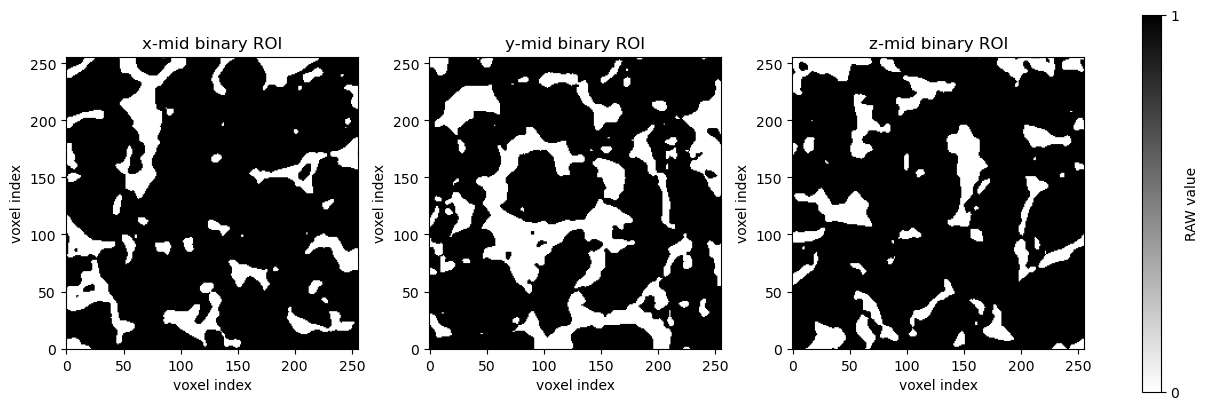

In [4]:
roi_mid = tuple(s // 2 for s in void_roi.shape)
binary_slice_specs = [
    ("x-mid", np.take(roi_raw, roi_mid[0], axis=0)),
    ("y-mid", np.take(roi_raw, roi_mid[1], axis=1)),
    ("z-mid", np.take(roi_raw, roi_mid[2], axis=2)),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.0), constrained_layout=True)
for ax, (title, binary_slice) in zip(axes, binary_slice_specs, strict=True):
    image = ax.imshow(binary_slice.T, origin="lower", vmin=0, vmax=1, cmap="gray_r")
    ax.set_title(f"{title} binary ROI")
    ax.set_xlabel("voxel index")
    ax.set_ylabel("voxel index")
fig.colorbar(image, ax=axes.ravel().tolist(), ticks=[0, 1], label="RAW value")

binary_figure_path = output_dir / "drp317_berea_roi_binary_midplanes.png"
fig.savefig(binary_figure_path, dpi=180)
binary_figure_path

## Build porosity and Kozeny-Carman permeability maps

In [5]:
porosity_map = porosity_map_from_binary(
    void_roi,
    block_shape=map_block_shape,
    voxel_size=(voxel_size_m, voxel_size_m, voxel_size_m),
    strict=True,
    metadata={
        "case": "drp317_berea_3d_roi",
        "raw_filename": raw_relpath.name,
        "raw_shape": full_shape,
        "raw_order": "C",
        "roi_origin": roi_origin,
        "roi_shape": roi_shape,
        "phase_convention": "0=void_or_pore, 1=solid",
        "experimental_porosity_pct": experimental_porosity_pct,
        "experimental_kabs_mD": experimental_kabs_mD,
    },
)

characteristic_length_m = min(porosity_map.cell_size)
permeability_map = permeability_map_from_porosity(
    porosity_map,
    characteristic_length=characteristic_length_m,
    kozeny_constant=kozeny_constant,
    solid_permeability=solid_permeability_m2,
    free_flow_permeability=free_flow_permeability_m2,
    max_permeability=max_permeability_m2,
    metadata={
        "closure_note": "Kozeny-Carman coefficient map for DRP-317 Berea ROI comparison",
        "scientific_caveat": "closure field, not a direct image-resolved permeability solve",
    },
)

porosity_h5 = output_dir / "drp317_berea_roi_porosity_map.h5"
permeability_h5 = output_dir / "drp317_berea_roi_permeability_map.h5"
save_porosity_map_hdf5(porosity_map, porosity_h5)
save_permeability_map_hdf5(permeability_map, permeability_h5)

loaded_porosity = load_porosity_map_hdf5(porosity_h5)
loaded_permeability = load_permeability_map_hdf5(permeability_h5)
assert np.allclose(loaded_porosity.values, porosity_map.values)
assert np.allclose(loaded_permeability.values, permeability_map.values)

map_summary = pd.DataFrame(
    [
        {
            "field": "porosity",
            "shape": str(porosity_map.shape),
            "min": float(np.min(porosity_map.values)),
            "mean": float(np.mean(porosity_map.values)),
            "max": float(np.max(porosity_map.values)),
            "units": "-",
        },
        {
            "field": "permeability",
            "shape": str(permeability_map.shape),
            "min": float(np.min(permeability_map.values)),
            "mean": float(np.mean(permeability_map.values)),
            "max": float(np.max(permeability_map.values)),
            "units": "m^2",
        },
    ]
)
display(map_summary)

,field,shape,min,mean,max,units
0,porosity,"(16, 16, 16)",0.000000e+00,2.131867e-01,1.000000e+00,-
1,permeability,"(16, 16, 16)",1.048250e-22,8.326022e-11,1.000000e-08,m^2


PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi_porosity_permeability_midplanes.png')

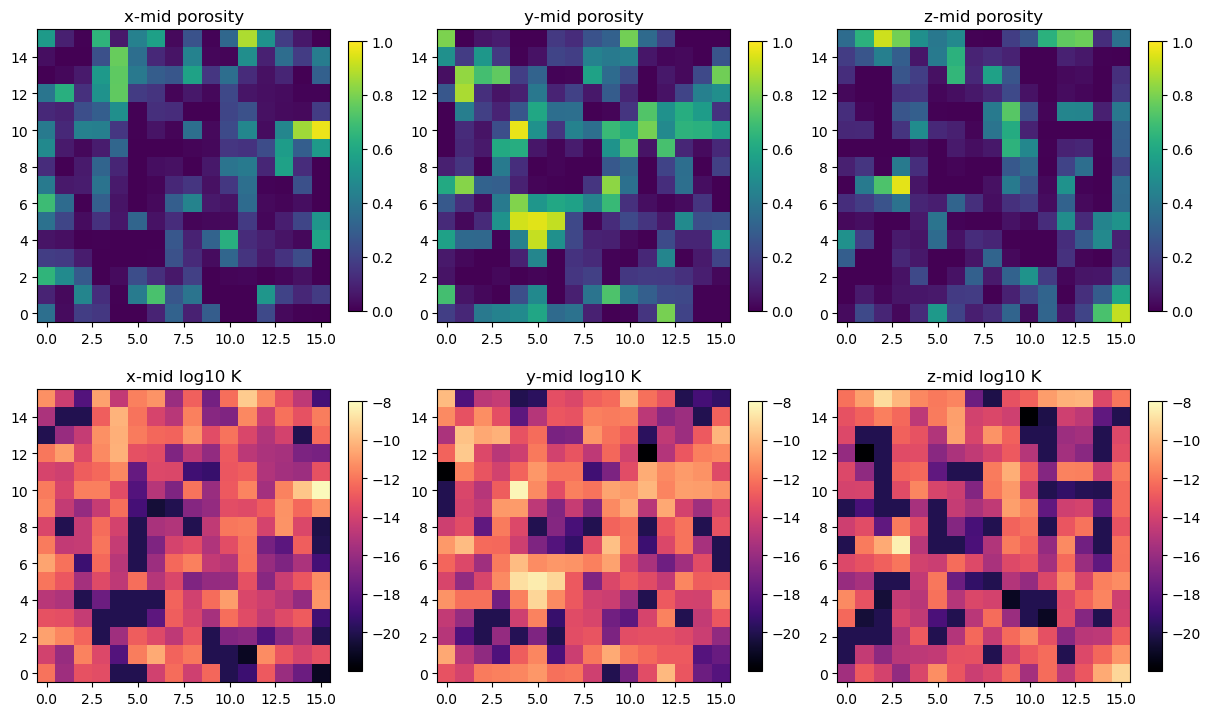

In [6]:
mid = tuple(s // 2 for s in porosity_map.shape)
map_slice_specs = [
    (
        "x-mid",
        np.take(porosity_map.values, mid[0], axis=0),
        np.take(permeability_map.values, mid[0], axis=0),
    ),
    (
        "y-mid",
        np.take(porosity_map.values, mid[1], axis=1),
        np.take(permeability_map.values, mid[1], axis=1),
    ),
    (
        "z-mid",
        np.take(porosity_map.values, mid[2], axis=2),
        np.take(permeability_map.values, mid[2], axis=2),
    ),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7.2), constrained_layout=True)
finite_log = np.log10(permeability_map.values[np.isfinite(permeability_map.values)])
for col, (title, porosity_slice, permeability_slice) in enumerate(map_slice_specs):
    im0 = axes[0, col].imshow(
        porosity_slice.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis"
    )
    axes[0, col].set_title(f"{title} porosity")
    fig.colorbar(im0, ax=axes[0, col], fraction=0.046, pad=0.04)

    with np.errstate(divide="ignore"):
        log_perm = np.log10(permeability_slice)
    im1 = axes[1, col].imshow(
        log_perm.T,
        origin="lower",
        vmin=float(np.min(finite_log)),
        vmax=float(np.max(finite_log)),
        cmap="magma",
    )
    axes[1, col].set_title(f"{title} log10 K")
    fig.colorbar(im1, ax=axes[1, col], fraction=0.046, pad=0.04)

map_figure_path = output_dir / "drp317_berea_roi_porosity_permeability_midplanes.png"
fig.savefig(map_figure_path, dpi=180)
map_figure_path

## Cell-centered 3-D TPFA Darcy-Darcy solve

In [7]:
resistor_results = {
    axis: solve_tpfa(
        permeability_map,
        flow_axis=axis,
        viscosity=mu_pa_s,
        pressure_inlet=pressure_inlet_pa,
        pressure_outlet=pressure_outlet_pa,
        solver_method=resistor_solver_method,
        solver_parameters=resistor_solver_parameters,
    )
    for axis in flow_axes
}

resistor_df = pd.DataFrame(
    [
        {
            "family": "map_resistor",
            "formulation": "darcy_darcy_tpfa_fv",
            "method": "TPFA finite-volume Darcy-Darcy",
            "axis": result.flow_axis,
            "mu_Pa_s": mu_pa_s,
            "pressure_inlet_Pa": pressure_inlet_pa,
            "pressure_outlet_Pa": pressure_outlet_pa,
            "delta_p_Pa": abs(pressure_inlet_pa - pressure_outlet_pa),
            "inlet_flux_m3_s": result.inlet_flow_rate,
            "outlet_flux_m3_s": result.outlet_flow_rate,
            "mass_imbalance_relative": result.mass_balance_error,
            "K_eq_m2": result.permeability,
            "K_eq_mD": result.permeability / M2_PER_MD,
            "matrix_nnz": result.matrix_nnz,
            "solve_seconds": result.solve_seconds,
            "solver_backend": (
                f"{result.solver_method}+{result.solver_info['preconditioner']}"
                if "preconditioner" in result.solver_info
                else result.solver_method
            ),
            "linear_residual_relative": result.residual_relative,
            "solver_info_json": json.dumps(result.solver_info, sort_keys=True),
        }
        for result in resistor_results.values()
    ]
)
display(resistor_df)

,family,formulation,method,axis,mu_Pa_s,pressure_inlet_Pa,pressure_outlet_Pa,delta_p_Pa,inlet_flux_m3_s,outlet_flux_m3_s,mass_imbalance_relative,K_eq_m2,K_eq_mD,matrix_nnz,solve_seconds,solver_backend,linear_residual_relative,solver_info_json
0,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,x,0.001,1.0,0.0,1.0,9.367182e-14,9.367182e-14,4.606022e-10,1.626247e-13,164.779456,27136,0.103071,cg+pyamg,7.510819e-11,"{""info"": 0, ""method"": ""cg"", ""preconditioner"": ..."
1,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,y,0.001,1.0,0.0,1.0,1.049320e-13,1.049320e-13,6.483196e-09,1.821736e-13,184.587351,27136,0.026536,cg+pyamg,8.961371e-11,"{""info"": 0, ""method"": ""cg"", ""preconditioner"": ..."
2,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,z,0.001,1.0,0.0,1.0,9.872170e-14,9.872169e-14,4.254317e-08,1.713918e-13,173.662761,27136,0.027140,cg+pyamg,5.454783e-11,"{""info"": 0, ""method"": ""cg"", ""preconditioner"": ..."


## FEniCSx USFEM micro-continuum solves

In [8]:
fem_output_dir = output_dir / "fenicsx_usfem_micro_continuum"
fem_output_dir.mkdir(parents=True, exist_ok=True)
fem_directional_path = fem_output_dir / f"{output_prefix}_fenicsx_usfem_directional.csv"
fem_directional_paths = [fem_directional_path]
fem_status_path = output_dir / "drp317_berea_roi_fem_status.json"

fem_status: dict[str, Any] = {
    "requested": bool(run_fem),
    "backend": "voids.fem.singlephase.solve_brinkman_usfem",
    "solver_backend": fem_solver_backend,
    "direct_options": fem_direct_options,
    "runs": [],
    "status": "not_requested" if not run_fem else "pending",
}

if run_fem:
    fem_problem = FEMMapProblem(
        permeability_map=permeability_map,
        porosity_map=porosity_map,
        viscosity=mu_pa_s,
        porosity_floor=fem_porosity_floor,
        permeability_floor=fem_k_floor,
    )
    fem_options = FEniCSSolverOptions(petsc_options=fem_direct_options)
    fem_rows: list[dict[str, object]] = []
    fem_status["status"] = "ok"
    for axis in flow_axes:
        start = time.perf_counter()
        result = solve_brinkman_usfem(
            fem_problem,
            flow_axis=axis,
            pressure_inlet=pressure_inlet_pa,
            pressure_outlet=pressure_outlet_pa,
            options=fem_options,
        )
        wall_seconds = time.perf_counter() - start
        fem_status["runs"].append(
            {
                "axis": axis,
                "status": "ok",
                "solve_seconds": result.solve_seconds,
                "wall_seconds": wall_seconds,
            }
        )
        fem_rows.append(
            {
                "family": "fem_micro_continuum",
                "formulation": result.formulation,
                "method": result.method,
                "solver_backend": f"fenicsx:petsc-lu-{fem_solver_backend}",
                "axis": result.flow_axis,
                "mu_Pa_s": mu_pa_s,
                "pressure_inlet_Pa": result.pressure_inlet,
                "pressure_outlet_Pa": result.pressure_outlet,
                "delta_p_Pa": result.pressure_drop,
                "outlet_flux_m3_s": result.flow_rate,
                "K_eq_m2": result.permeability,
                "K_eq_mD": result.permeability / M2_PER_MD,
                "solve_seconds": result.solve_seconds,
                "wall_seconds": wall_seconds,
                "solver_options_json": json.dumps(fem_direct_options, sort_keys=True),
                "metadata_json": json.dumps(result.metadata, sort_keys=True),
            }
        )
    fem_df = pd.DataFrame(fem_rows)
    fem_df.to_csv(fem_directional_path, index=False)
    fem_status_path.write_text(json.dumps(fem_status, indent=2), encoding="utf-8")
elif fem_directional_path.exists():
    fem_df = pd.read_csv(fem_directional_path)
    fem_status["status"] = "loaded_existing"
else:
    fem_df = pd.DataFrame()

fem_status

{'requested': True,
 'backend': 'voids.fem.singlephase.solve_brinkman_usfem',
 'solver_backend': 'superlu_dist',
 'direct_options': {'ksp_type': 'preonly',
  'pc_type': 'lu',
  'pc_factor_mat_solver_type': 'superlu_dist',
  'ksp_error_if_not_converged': True,
  'pc_factor_shift_type': 'nonzero',
  'pc_factor_shift_amount': 1e-12},
 'runs': [{'axis': 'x',
   'status': 'ok',
   'solve_seconds': 14.54521291598212,
   'wall_seconds': 14.899100249982439},
  {'axis': 'y',
   'status': 'ok',
   'solve_seconds': 14.831761082983576,
   'wall_seconds': 14.961976332997438},
  {'axis': 'z',
   'status': 'ok',
   'solve_seconds': 14.186030916986056,
   'wall_seconds': 14.31540329195559}],
 'status': 'ok'}

In [9]:
display(fem_df)

,family,formulation,method,solver_backend,axis,mu_Pa_s,pressure_inlet_Pa,pressure_outlet_Pa,delta_p_Pa,outlet_flux_m3_s,K_eq_m2,K_eq_mD,solve_seconds,wall_seconds,solver_options_json,metadata_json
0,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-superlu_dist,x,0.001,1.0,0.0,1.0,2.104004e-14,3.652784e-14,37.011835,14.545213,14.899100,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""alpha_edge"": 1.0, ""m_t"": 0.3333333333333333,..."
1,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-superlu_dist,y,0.001,1.0,0.0,1.0,3.068890e-14,5.327935e-14,53.985295,14.831761,14.961976,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""alpha_edge"": 1.0, ""m_t"": 0.3333333333333333,..."
2,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-superlu_dist,z,0.001,1.0,0.0,1.0,2.417506e-14,4.197059e-14,42.526695,14.186031,14.315403,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""alpha_edge"": 1.0, ""m_t"": 0.3333333333333333,..."


## Compare PNM, resistor, FEM, and experiment

In [10]:
comparison_rows: list[dict[str, object]] = []


for row in resistor_df.to_dict(orient="records"):
    comparison_rows.append(
        {
            "family": row["family"],
            "formulation": row["formulation"],
            "method": row["method"],
            "solver_backend": "",
            "axis": row["axis"],
            "K_m2": float(row["K_eq_m2"]),
            "K_mD": float(row["K_eq_mD"]),
            "solve_seconds": float(row["solve_seconds"]),
        }
    )

if not fem_df.empty:
    for row in fem_df.to_dict(orient="records"):
        comparison_rows.append(
            {
                "family": row["family"],
                "formulation": row["formulation"],
                "method": row["method"],
                "solver_backend": row.get("solver_backend", ""),
                "axis": row["axis"],
                "K_m2": float(row["K_eq_m2"]),
                "K_mD": float(row["K_eq_mD"]),
                "solve_seconds": float(row["solve_seconds"]),
            }
        )

if pnm_directional_path.exists():
    pnm_directional = pd.read_csv(pnm_directional_path)
    for row in pnm_directional.to_dict(orient="records"):
        comparison_rows.append(
            {
                "family": "extracted_pnm",
                "formulation": "pore_network_model",
                "method": row["backend_label"],
                "solver_backend": "",
                "axis": row["axis"],
                "K_m2": float(row["k_m2"]),
                "K_mD": float(row["k_mD"]),
                "solve_seconds": np.nan,
            }
        )
else:
    pnm_directional = pd.DataFrame()
    print(f"PNM directional summary not found: {pnm_directional_path}")

for axis in flow_axes:
    comparison_rows.append(
        {
            "family": "experimental",
            "formulation": "bulk_experiment",
            "method": "Experimental Kabs",
            "solver_backend": "",
            "axis": axis,
            "K_m2": experimental_kabs_mD * M2_PER_MD,
            "K_mD": experimental_kabs_mD,
            "solve_seconds": np.nan,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.sort_values(["axis", "family", "method"]))

,family,formulation,method,solver_backend,axis,K_m2,K_mD,solve_seconds
15,experimental,bulk_experiment,Experimental Kabs,,x,1.194177e-13,121.000000,NaN
6,extracted_pnm,pore_network_model,Native maximal-ball,,x,8.936247e-14,90.546519,NaN
12,extracted_pnm,pore_network_model,PREGO,,x,2.775306e-13,281.207868,NaN
9,extracted_pnm,pore_network_model,PoreSpy snow2,,x,1.430193e-13,144.914263,NaN
3,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman USFEM CG1 x DG1,fenicsx:petsc-lu-superlu_dist,x,3.652784e-14,37.011835,14.545213
0,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,,x,1.626247e-13,164.779456,0.103071
16,experimental,bulk_experiment,Experimental Kabs,,y,1.194177e-13,121.000000,NaN
7,extracted_pnm,pore_network_model,Native maximal-ball,,y,7.254374e-14,73.504943,NaN
13,extracted_pnm,pore_network_model,PREGO,,y,2.355568e-13,238.677965,NaN
10,extracted_pnm,pore_network_model,PoreSpy snow2,,y,1.329440e-13,134.705474,NaN


In [11]:
ratio_rows: list[dict[str, object]] = []
for _, row in comparison_df.iterrows():
    k_row = float(row["K_mD"])
    ratio_rows.append(
        {
            "axis": row["axis"],
            "family": row["family"],
            "method": row["method"],
            "K_method_mD": k_row,
            "K_experimental_mD": experimental_kabs_mD,
            "method_over_experiment": k_row / experimental_kabs_mD,
            "experiment_over_method": experimental_kabs_mD / k_row,
        }
    )
ratio_df = pd.DataFrame(ratio_rows)
display(ratio_df.sort_values(["axis", "family", "method"]))

,axis,family,method,K_method_mD,K_experimental_mD,method_over_experiment,experiment_over_method
15,x,experimental,Experimental Kabs,121.000000,121.0,1.000000,1.000000
6,x,extracted_pnm,Native maximal-ball,90.546519,121.0,0.748318,1.336330
12,x,extracted_pnm,PREGO,281.207868,121.0,2.324032,0.430287
9,x,extracted_pnm,PoreSpy snow2,144.914263,121.0,1.197639,0.834976
3,x,fem_micro_continuum,Darcy-Brinkman USFEM CG1 x DG1,37.011835,121.0,0.305883,3.269225
0,x,map_resistor,TPFA finite-volume Darcy-Darcy,164.779456,121.0,1.361814,0.734315
16,y,experimental,Experimental Kabs,121.000000,121.0,1.000000,1.000000
7,y,extracted_pnm,Native maximal-ball,73.504943,121.0,0.607479,1.646148
13,y,extracted_pnm,PREGO,238.677965,121.0,1.972545,0.506959
10,y,extracted_pnm,PoreSpy snow2,134.705474,121.0,1.113268,0.898256


## Visual diagnostics

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi_model_comparison.png')

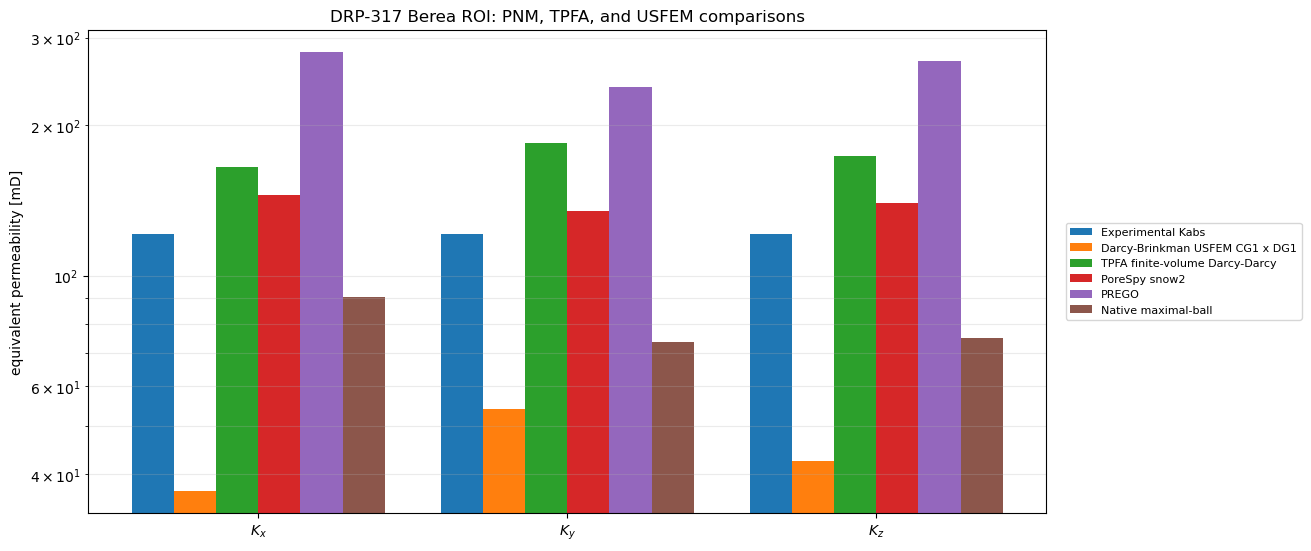

In [12]:
plot_df = comparison_df.copy()
axis_order = ["x", "y", "z"]
method_order = [
    "Experimental Kabs",
    "Darcy-Brinkman USFEM CG1 x DG1",
    "TPFA finite-volume Darcy-Darcy",
    "PoreSpy snow2",
    "PREGO",
    "Native maximal-ball",
]
available_methods = [
    method for method in method_order if method in set(plot_df["method"])
]

fig, ax = plt.subplots(figsize=(13, 5.4), constrained_layout=True)
bar_width = 0.82 / max(len(available_methods), 1)
x_positions = np.arange(len(axis_order), dtype=float)

for method_index, method in enumerate(available_methods):
    subset = plot_df[plot_df["method"] == method]
    values = []
    for axis in axis_order:
        match = subset[subset["axis"] == axis]
        values.append(float(match.iloc[0]["K_mD"]) if not match.empty else np.nan)
    offset = (method_index - 0.5 * (len(available_methods) - 1)) * bar_width
    ax.bar(x_positions + offset, values, width=bar_width, label=method)

ax.set_yscale("log")
ax.set_xticks(x_positions)
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_ylabel("equivalent permeability [mD]")
ax.set_title("DRP-317 Berea ROI: PNM, TPFA, and USFEM comparisons")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

comparison_plot_path = output_dir / "drp317_berea_roi_model_comparison.png"
fig.savefig(comparison_plot_path, dpi=200)
comparison_plot_path

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi_model_solve_time.png')

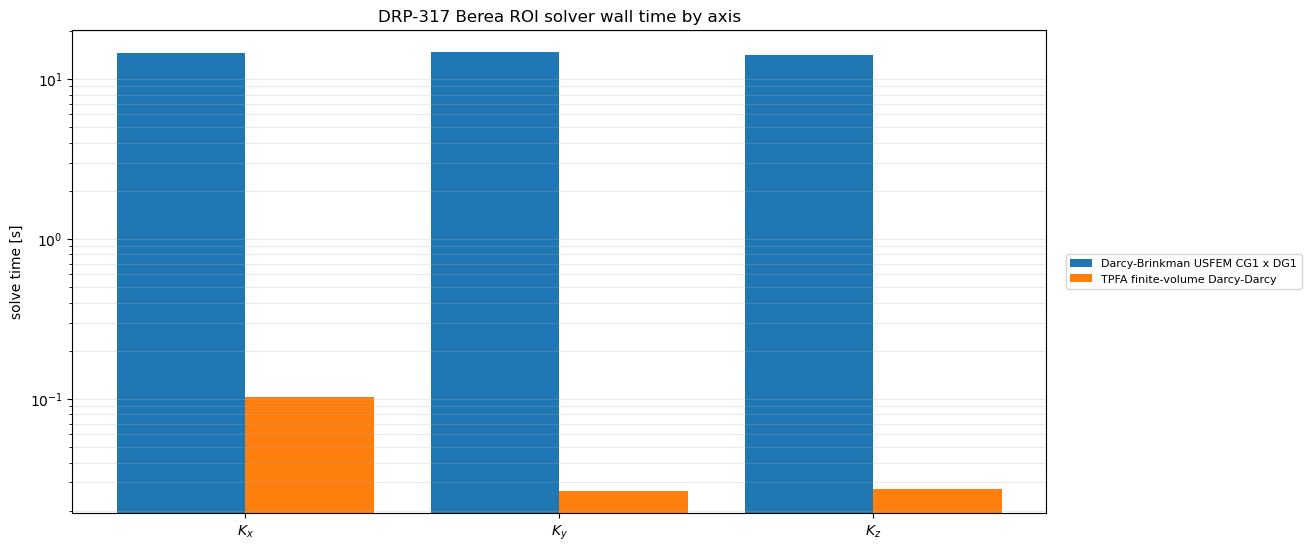

In [13]:
timing_df = plot_df[np.isfinite(plot_df["solve_seconds"])].copy()
available_timing_methods = [
    method for method in method_order if method in set(timing_df["method"])
]

fig, ax = plt.subplots(figsize=(13, 5.4), constrained_layout=True)
bar_width = 0.82 / max(len(available_timing_methods), 1)

for method_index, method in enumerate(available_timing_methods):
    subset = timing_df[timing_df["method"] == method]
    values = []
    for axis in axis_order:
        match = subset[subset["axis"] == axis]
        values.append(
            float(match.iloc[0]["solve_seconds"]) if not match.empty else np.nan
        )
    offset = (method_index - 0.5 * (len(available_timing_methods) - 1)) * bar_width
    ax.bar(x_positions + offset, values, width=bar_width, label=method)

ax.set_yscale("log")
ax.set_xticks(x_positions)
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_ylabel("solve time [s]")
ax.set_title("DRP-317 Berea ROI solver wall time by axis")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

time_plot_path = output_dir / "drp317_berea_roi_model_solve_time.png"
fig.savefig(time_plot_path, dpi=200)
time_plot_path

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/41_mwe_drp317_berea_map_resistor_micro_continuum/drp317_berea_roi_model_comparison_heatmap.png')

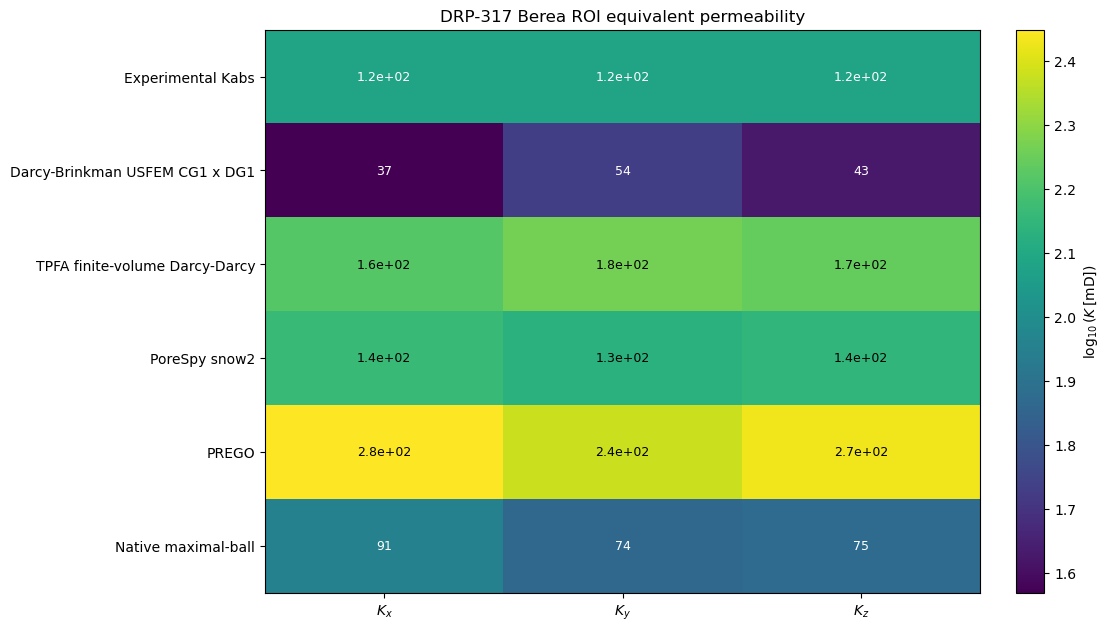

In [14]:
heatmap_df = (
    plot_df.pivot_table(index="method", columns="axis", values="K_mD", aggfunc="first")
    .reindex(available_methods)
    .reindex(columns=axis_order)
)
with np.errstate(divide="ignore", invalid="ignore"):
    heatmap_values = np.log10(heatmap_df.to_numpy(dtype=float))

fig, ax = plt.subplots(figsize=(11, 6.2), constrained_layout=True)
finite_values = heatmap_values[np.isfinite(heatmap_values)]
image = ax.imshow(
    heatmap_values,
    cmap="viridis",
    aspect="auto",
    vmin=float(np.min(finite_values)),
    vmax=float(np.max(finite_values)),
)
ax.set_xticks(np.arange(len(axis_order)))
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_title("DRP-317 Berea ROI equivalent permeability")
fig.colorbar(image, ax=ax, label=r"$\log_{10}(K\,[\mathrm{mD}])$")

for row_index, method in enumerate(heatmap_df.index):
    for col_index, axis in enumerate(axis_order):
        value = heatmap_df.loc[method, axis]
        if not np.isfinite(value):
            continue
        ax.text(
            col_index,
            row_index,
            f"{value:.2g}",
            ha="center",
            va="center",
            color=(
                "white"
                if heatmap_values[row_index, col_index] < np.median(finite_values)
                else "black"
            ),
            fontsize=9,
        )

comparison_heatmap_path = output_dir / "drp317_berea_roi_model_comparison_heatmap.png"
fig.savefig(comparison_heatmap_path, dpi=200)
comparison_heatmap_path

## Save tables

In [15]:
roi_summary_path = output_dir / "drp317_berea_roi_summary.csv"
phase_summary_path = output_dir / "drp317_berea_roi_phase_summary.csv"
map_summary_path = output_dir / "drp317_berea_roi_map_summary.csv"
resistor_path = output_dir / "drp317_berea_roi_map_resistor_directional.csv"
comparison_path = output_dir / "drp317_berea_roi_model_comparison.csv"
ratio_path = output_dir / "drp317_berea_roi_model_ratios_to_experiment.csv"

roi_summary.to_csv(roi_summary_path, index=False)
phase_summary.to_csv(phase_summary_path, index=False)
map_summary.to_csv(map_summary_path, index=False)
resistor_df.to_csv(resistor_path, index=False)
comparison_df.to_csv(comparison_path, index=False)
ratio_df.to_csv(ratio_path, index=False)
fem_status_path.write_text(json.dumps(fem_status, indent=2), encoding="utf-8")

saved_paths = [
    porosity_h5,
    permeability_h5,
    roi_summary_path,
    phase_summary_path,
    map_summary_path,
    resistor_path,
    comparison_path,
    ratio_path,
    fem_status_path,
    binary_figure_path,
    map_figure_path,
    comparison_plot_path,
    time_plot_path,
    comparison_heatmap_path,
]
saved_paths.extend(path for path in fem_directional_paths if path.exists())

for axis, result in resistor_results.items():
    pressure_path = output_dir / f"drp317_berea_roi_map_resistor_pressure_{axis}.npy"
    np.save(pressure_path, result.pressure)
    saved_paths.append(pressure_path)

pd.DataFrame({"saved_path": [str(path) for path in saved_paths]})

,saved_path
0,/Users/dtvolpatto/Work/voids/notebooks/outputs...
1,/Users/dtvolpatto/Work/voids/notebooks/outputs...
2,/Users/dtvolpatto/Work/voids/notebooks/outputs...
3,/Users/dtvolpatto/Work/voids/notebooks/outputs...
4,/Users/dtvolpatto/Work/voids/notebooks/outputs...
5,/Users/dtvolpatto/Work/voids/notebooks/outputs...
6,/Users/dtvolpatto/Work/voids/notebooks/outputs...
7,/Users/dtvolpatto/Work/voids/notebooks/outputs...
8,/Users/dtvolpatto/Work/voids/notebooks/outputs...
9,/Users/dtvolpatto/Work/voids/notebooks/outputs...


## Interpretation notes

- The PoreSpy PNM row is the closest existing extracted-network estimate to
  the experimental Berea permeability for this ROI.
- The Darcy-Brinkman FEM row is the micro-continuum comparison because it uses
  both `phi` and `K(phi)`. The TPFA finite-volume Darcy-Darcy row is a pure
  permeability-coefficient baseline.
- The map-based values are sensitive to `map_block_shape`, the Kozeny-Carman
  characteristic length, and the permeability caps. These parameters are
  closure assumptions, not measured Berea properties.
- Direct-image LBM DNS is left out of this `256^3` ROI run because it is a
  much larger CPU target than the `75^3` DNS run in notebook 42.